# pyetc_iredMUSE Quick Look

A guided introduction to the iredMUSE Exposure Time Calculator.

Original: pyetc_WST from Roland Bacon (WST) [git:pyetc_wst](https://github.com/ferromatteo/pyetc_wst)

Adapted: Nicolas Bouché (iredMUSE) [git:pyetc_iredmuse](https://github.com/nicolas-f-bouche/pyetc_iredmuse/)

This notebook shows how to:
- build a complete observation dictionary;
- create calibrated source spectra and source images;
- compute SNR spectra, SNR at one wavelength, and exposure times;
- use automatic spatial coaddition;
- inspect noise components and make useful plots.

The examples use the installed `pyetc_ifs` package [git:pyetc_iredmuse](https://github.com/nicolas-f-bouche/pyetc_iredmuse/) and static sky tables, so they do not require a SkyCalc network request.

## 1. Setup

The main object is `iredMUSE`. It contains the instrument configuration and inherits the ETC calculation methods.

In [1]:
%load_ext autoreload
%autoreload 2

In [30]:
import numpy as np
import matplotlib.pyplot as plt

from pyetc_ifs import iredMUSE, __version__
from pyetc_ifs.etc import snr_in_window, plot_noise_components

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 12,
})

redmuse = iredMUSE(log='INFO', skip_dataload=False, ron=6)
print(f'pyetc_ifs version: {__version__}')


[INFO] Reading ifs zband into self._transdata
[INFO] Reading ifs Jband into self._transdata
[INFO] Reading ifs zJband into self._transdata
pyetc_ifs version: 0.4


In [58]:
redmuse.info()

[INFO] ETC version 0.3 release date 24 Sep 2026
[INFO] 	- cleaned up the code and added more documentation
[INFO] Telescope Based on Prelim Concept version 26/06/2026
[INFO] Diameter: 8.00 m Eff. Area IFS: 48.5 m2
[INFO] IFS type IFS Channel zband
[INFO] 	 Throughput model: Throughput estimations by Nicolas Bouché
[INFO] 	 Configuration version: 14/07/2026
[INFO] 	 Spaxel size: 0.22 arcsec Image Quality tel and ins fwhm: 0.10 and 0.13 arcsec beta: 2.80 
[INFO] 	 Wavelength range [ 9500. 11300.] A step 0.90 A LSF 2.2 pix Npix 2001
[INFO] 	 Instrument transmission peak 0.32 at 10667 - min 0.30 at 9500
[INFO] 	 Detector RON 6.0 e- Dark 72.0 e-/h
[INFO] IFS type IFS Channel Jband
[INFO] 	 Throughput model: Throughput estimations by Nicolas Bouché
[INFO] 	 Configuration version: 14/07/2026
[INFO] 	 Spaxel size: 0.22 arcsec Image Quality tel and ins fwhm: 0.10 and 0.13 arcsec beta: 2.80 
[INFO] 	 Wavelength range [11300. 13000.] A step 1.00 A LSF 2.2 pix Npix 1701
[INFO] 	 Instrument transmi

## 2. Explore the available instruments

The package has two IFS channels and four channels for each MOS mode. Instrument dictionaries contain wavelength limits, dispersion, spatial sampling, detector noise, and throughput curves.

In [57]:
ifs_channels=redmuse.ifs['channels']
family = getattr(redmuse, 'ifs')
print(f'{family_name.upper():6s}: {family["channels"]}')

ins = redmuse.ifs['zJband']
print('\n IFS redmuse summary:')
for key in ('lbda1', 'lbda2', 'dlbda', 'spaxel_size', 'lsfpix', 'ron', 'dcurrent'):
    print(f'  {key:12s}: {ins[key]}')

ZBAND : ['zband', 'Jband', 'zJband']

 IFS redmuse summary:
  lbda1       : 9300
  lbda2       : 13000
  dlbda       : 2.0
  spaxel_size : 0.22
  lsfpix      : 2.2
  ron         : 6
  dcurrent    : 72.0


## 3. Build an observation dictionary

`full_obs` is the user-facing dictionary. The names are intentionally explicit: instrument, channel, exposure setup, source spectrum, morphology, sky, and requested coadds all live here.

For a continuum source, `Obj_SED` can be `template`, `bb`, `pl`, `uniform`, or `upload`. For an emission line use `line`. Spatial types are `ps`, `resolved`, and `sb`.

In [32]:
full_obs = {
    # Instrument
    'INS': 'ifs',
    'CH': 'zJband',

    # Exposure and target SNR
    'DIT': 900,
    'NDIT': 3,
    'SNR': 5,
    'Lam_Ref': 10000,

    # Observing conditions
    'SEE': 0.8,
    'AM': 1.2,
    'PWV': 3.5,
    'FLI': 0,
    'SKYCALC': False,
    'MOON_SEP': 45,
    'GLAO': False,

    # Continuum source calibrated to a magnitude
    'Obj_SED': 'template',
    'SED_Name': 'Pickles_A0V',
    'OBJ_MAG': 22,
    'MAG_SYS': 'AB',
    'MAG_FIL': 'rSDSS',
    'Z': 0,
    'BB_Temp': 9000,
    'PL_Index': -2,

    # Line-source fields, unused for this continuum example
    'SEL_FLUX': 5e-17,
    'SEL_CWAV': 8000,
    'SEL_FWHM': 5,

    # Spatial model and coadds
    'Obj_Spat_Dis': 'ps',
    'IMA': 'moffat',
    'IMA_FWHM': 0.8,
    'IMA_BETA': 2.8,
    'Sersic_Reff': 1.0,
    'Sersic_Ind': 2.0,
    'COADD_WL': 1,
    'COADD_XY': 'best',

    # Optional wavelength-window target mode
    'SNR_RANGE': False,
    'LAM_WIN1': 9500,
    'LAM_WIN2': 10500,

    # MOS-only field; harmless for IFS
    'OBJ_FIB_DISP': 0,
}

for key, value in full_obs.items():
    print(f'{key:14s}: {value}')

INS           : ifs
CH            : zJband
DIT           : 900
NDIT          : 3
SNR           : 5
Lam_Ref       : 10000
SEE           : 0.8
AM            : 1.2
PWV           : 3.5
FLI           : 0
SKYCALC       : False
MOON_SEP      : 45
GLAO          : False
Obj_SED       : template
SED_Name      : Pickles_A0V
OBJ_MAG       : 22
MAG_SYS       : AB
MAG_FIL       : rSDSS
Z             : 0
BB_Temp       : 9000
PL_Index      : -2
SEL_FLUX      : 5e-17
SEL_CWAV      : 8000
SEL_FWHM      : 5
Obj_Spat_Dis  : ps
IMA           : moffat
IMA_FWHM      : 0.8
IMA_BETA      : 2.8
Sersic_Reff   : 1.0
Sersic_Ind    : 2.0
COADD_WL      : 1
COADD_XY      : best
SNR_RANGE     : False
LAM_WIN1      : 9500
LAM_WIN2      : 10500
OBJ_FIB_DISP  : 0


## 4. Turn the dictionary into ETC inputs

`build_obs_full` performs the bookkeeping: it selects the instrument, loads the sky, builds and calibrates the source spectrum, applies the LSF, and creates an image only when needed.

It returns:
- `con`: selected instrument configuration;
- `ob`: internal observation dictionary;
- `spe`: processed source spectrum used by the ETC;
- `im`: source image for resolved sources, otherwise `None`;
- `spe_input`: source spectrum before the instrument processing.

In [33]:
con, ob, spe, im, spe_input = redmuse.build_obs_full(full_obs)

print('Selected configuration:', con['name'], con['chan'])
print('Internal image type:', ob['ima_type'])
print('Source spectrum:', spe.shape[0], 'spectral pixels')
print('Source image:', im)

Selected configuration: ifs zJband
Internal image type: ps
Source spectrum: 1851 spectral pixels
Source image: None


## 5. Inspect the calibrated source and throughput

Before calculating SNR it is useful to check what is actually entering the detector model: the calibrated source spectrum and the total instrument transmission (excluding atmosphere).

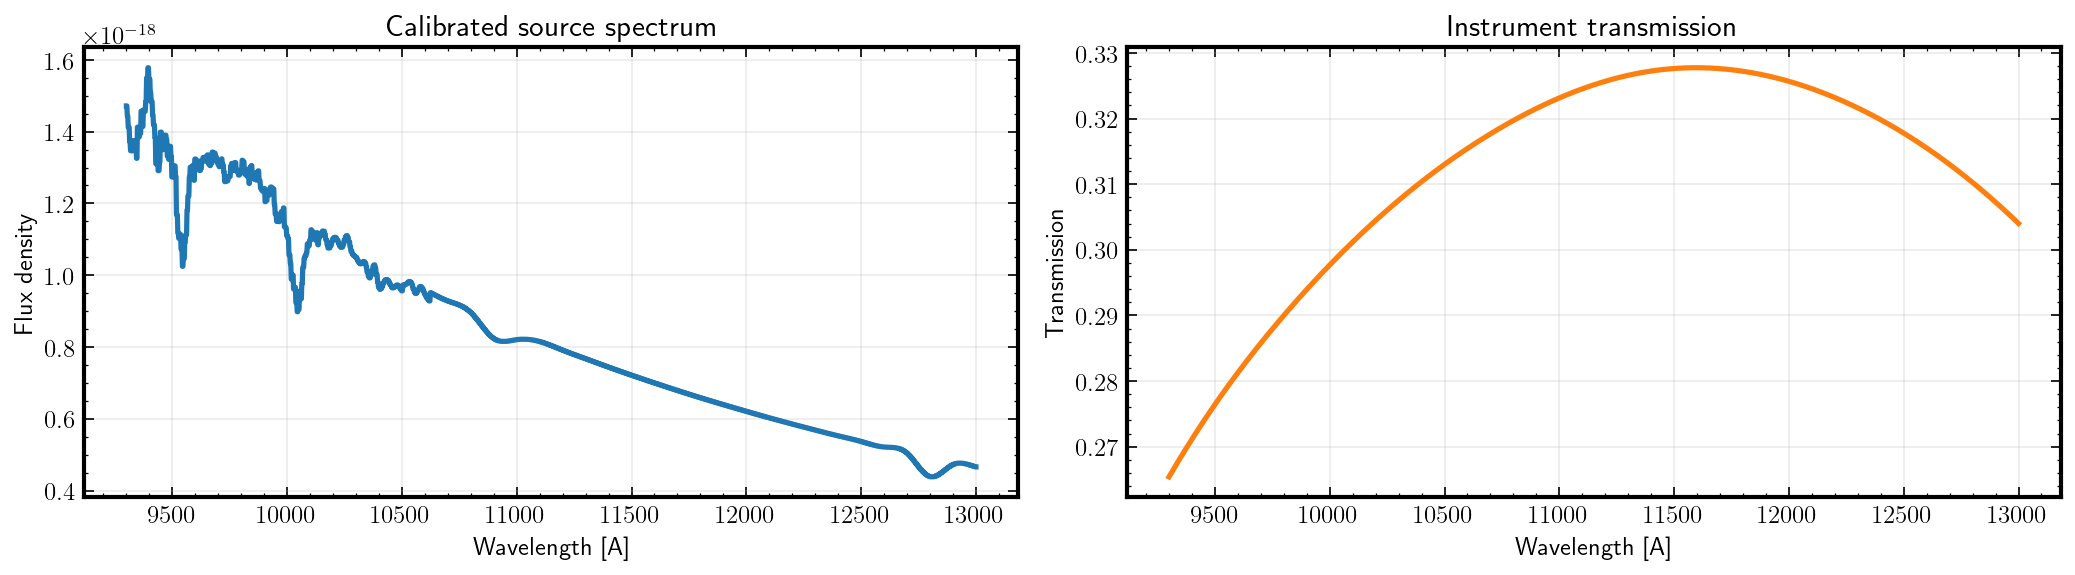

In [34]:
wave = spe.wave.coord()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(wave, spe.data, color='tab:blue')
axes[0].set(title='Calibrated source spectrum', xlabel='Wavelength [A]', ylabel='Flux density')
axes[1].plot(con['instrans'].wave.coord(), con['instrans'].data, color='tab:orange')
axes[1].set(title='Instrument transmission', xlabel='Wavelength [A]', ylabel='Transmission')
plt.tight_layout()
plt.show()

## 6. Compute the SNR spectrum

`snr_from_source` is the main full-spectrum calculation. For IFS, `res['spec']` refers to the selected spatial aperture and `res['peak']` refers to the central spaxel.

With `COADD_XY='best'`, the ETC chooses the square aperture that maximizes the full aperture-SNR metric at the channel centre in this full-spectrum DIT+NDIT calculation. The chosen integer is written back to `ob['ima_coadd']`.

In [35]:
res_snr = redmuse.snr_from_source(con, im, spe, debug=False)

print(f'Chosen spatial coadd: {ob["ima_coadd"]} x {ob["ima_coadd"]}')
print(f'Median aperture SNR: {np.nanmedian(res_snr["spec"]["snr"].data):.2f}')
print('Result groups:', list(res_snr.keys()))

Chosen spatial coadd: 4 x 4
Median aperture SNR: 2.27
Result groups: ['input', 'obs', 'peak', 'spec', 'flag_sat', 'frac_sat', 'sat_limit']


/home/nbouche/miniconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


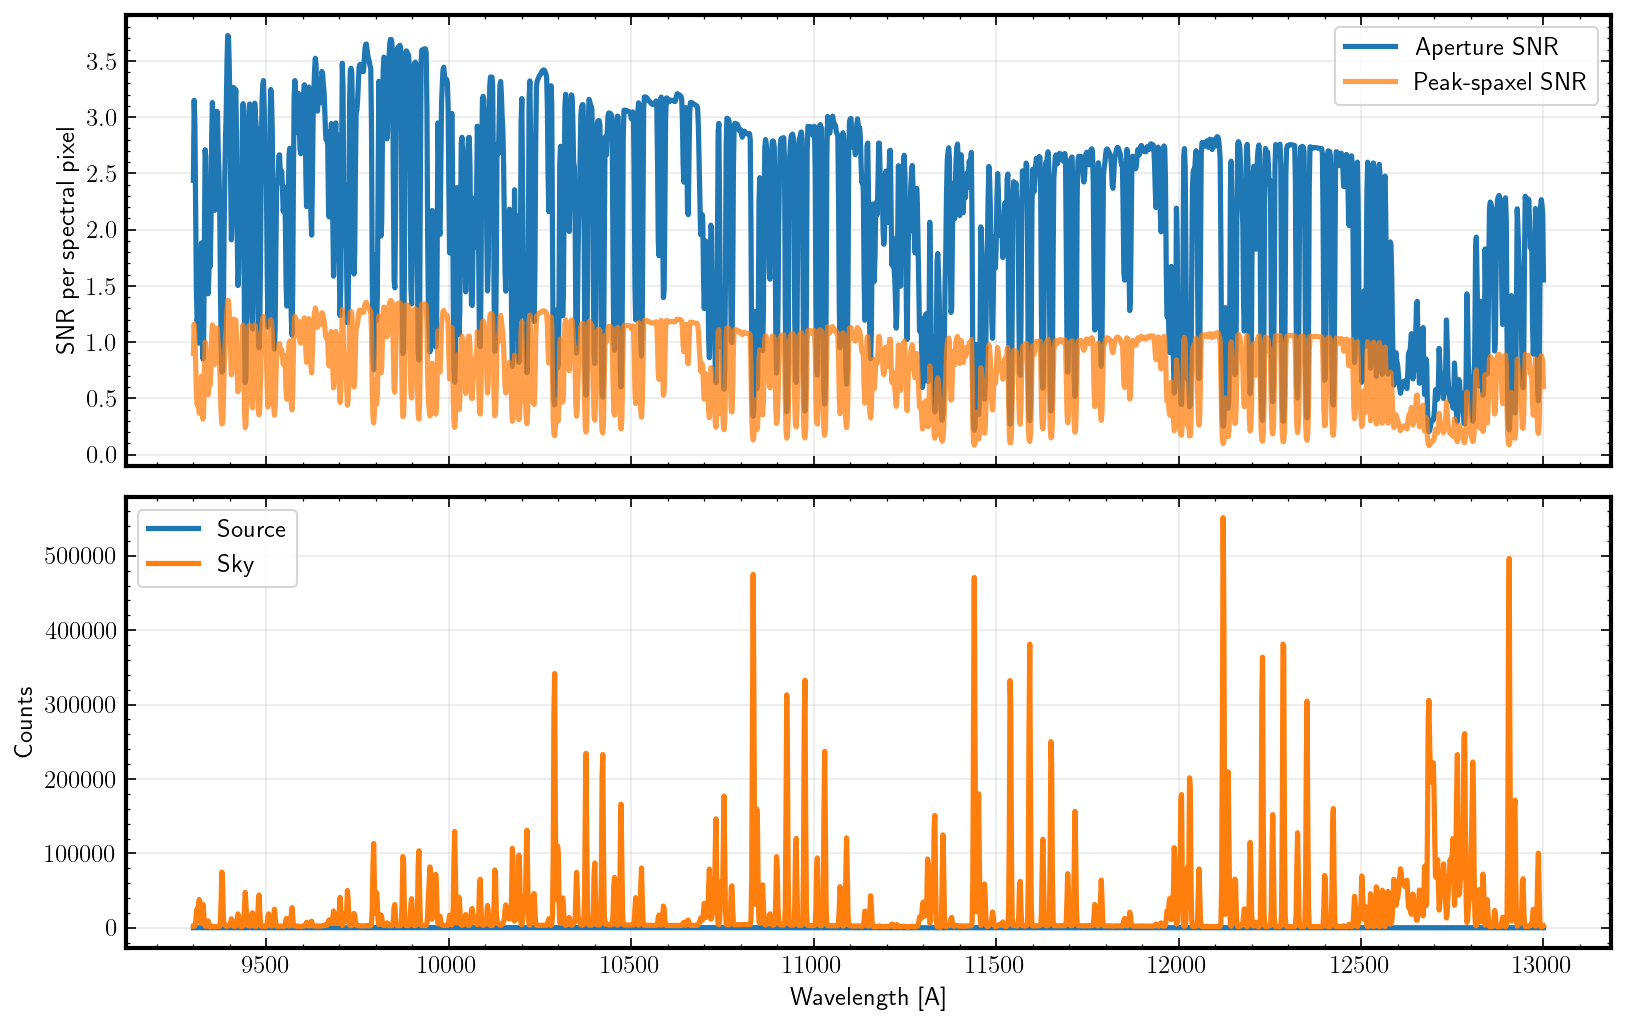

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(res_snr['spec']['snr'].wave.coord(), res_snr['spec']['snr'].data, label='Aperture SNR')
axes[0].plot(res_snr['peak']['snr'].wave.coord(), res_snr['peak']['snr'].data, label='Peak-spaxel SNR', alpha=0.75)
axes[0].set_ylabel('SNR per spectral pixel')
axes[0].legend()

axes[1].plot(res_snr['spec']['nph_source'].wave.coord(), res_snr['spec']['nph_source'].data, label='Source')
axes[1].plot(res_snr['spec']['nph_sky'].wave.coord(), res_snr['spec']['nph_sky'].data, label='Sky')
axes[1].set(xlabel='Wavelength [A]', ylabel='Counts')
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Read the noise budget

The total variance contains source Poisson noise, sky Poisson noise, dark current, and read-out noise. The result dictionary stores both the total noise and the fractional contribution of each component.

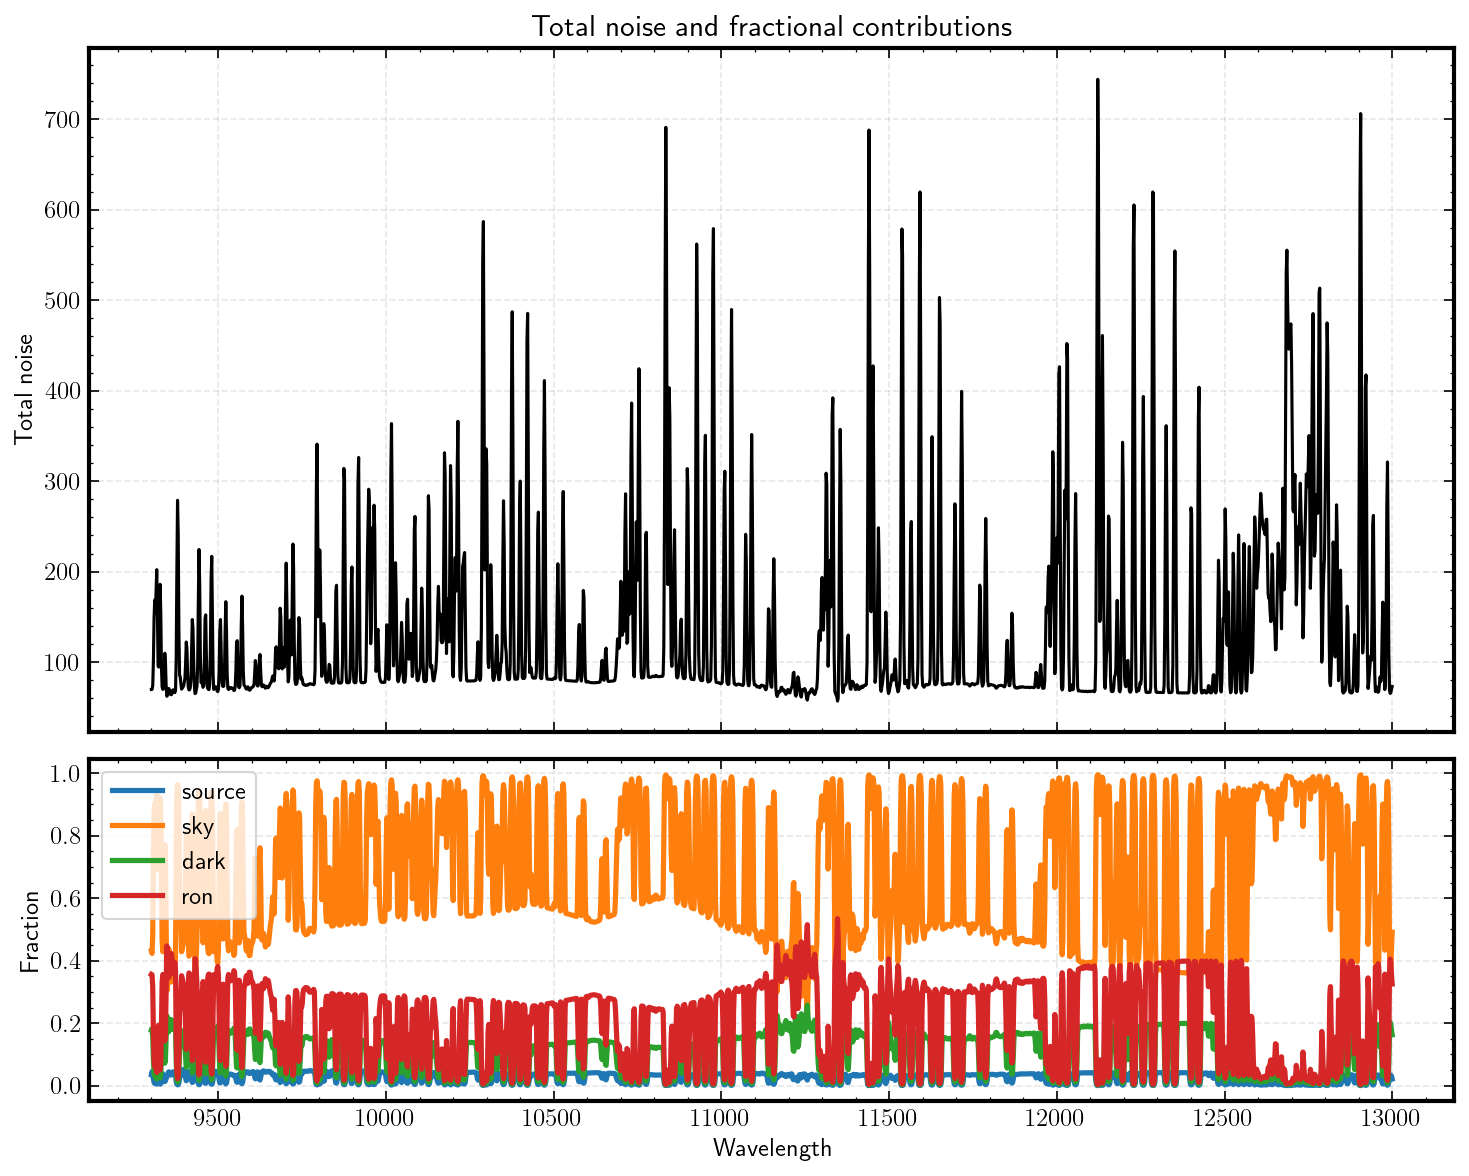

In [37]:
plot_noise_components(res_snr['spec']['noise'])

## 8. SNR at one wavelength

`snr_at_wave` is a fast calculation for a single wavelength. It is useful when scanning a wavelength grid, comparing channels, or solving for a limiting magnitude.

In [38]:
target_wave = 11000
res_at_wave = redmuse.snr_at_wave(con, im, spe, wave_target=target_wave)

print(f'Requested wavelength: {target_wave} A')
print(f'Used wavelength:      {res_at_wave["wave"]:.2f} A')
print(f'Aperture SNR:         {res_at_wave["snr_aperture"]:.3f}')
if 'snr_peak' in res_at_wave:
    print(f'Peak-spaxel SNR:      {res_at_wave["snr_peak"]:.3f}')

Requested wavelength: 11000 A
Used wavelength:      11000.00 A
Aperture SNR:         2.892
Peak-spaxel SNR:      1.093


## 9. Exposure-time calculations

Set `compute='dit'` to solve for DIT at fixed NDIT, `compute='ndit'` to solve for NDIT at fixed DIT, or `compute='best'` to search for a useful DIT/NDIT combination while respecting saturation.

These methods use `SNR` and `Lam_Ref` from the observation dictionary for a single-wavelength target.

In [42]:
# Work on a copy so the original example remains easy to rerun.
time_obs = dict(full_obs)
time_obs.update({'DIT': 600, 'NDIT': 3, 'SNR': 5, 'Lam_Ref': 10000})
con_t, ob_t, spe_t, im_t, _ = redmuse.build_obs_full(time_obs)

res_time_ndit = redmuse.time_from_source(con_t, im_t, spe_t, compute='ndit', debug=False)
print('NDIT solution:', res_time_ndit)

NDIT solution: {'ndit': np.float64(21.680977336249924), 'dit_sat': np.float64(3916.866424625163), 'flag_sat': False, 'input': {'flux_source': <Spectrum(shape=(1851,), unit='', dtype='float64')>, 'atm_abs': <Spectrum(shape=(1851,), unit='', dtype='float64')>, 'ins_trans': <Spectrum(shape=(1851,), unit='', dtype='float64')>, 'atm_emi': <Spectrum(shape=(1851,), unit='', dtype='float64')>, 'QE_trans': <Spectrum(shape=(1851,), unit='', dtype='float64')>, 'tel_trans': <Spectrum(shape=(1851,), unit='', dtype='float64')>, 'ins_noQE_trans': <Spectrum(shape=(1851,), unit='', dtype='float64')>, 'total_trans': <Spectrum(shape=(1851,), unit='', dtype='float64')>}, 'obs': {'INS': 'ifs', 'CH': 'zJband', 'seeing': 0.8, 'seeing_input': 0.8, 'ndit': np.float64(21.680977336249924), 'dit': 600, 'spec_type': 'cont', 'spec_specific': 'template', 'ima_type': 'ps', 'ima_coadd': 4, 'skycalc': False, 'airmass': 1.2, 'pwv': 3.5, 'fli': 0, 'moon_target_sep': 45, 'wave_line_center': 8000, 'wave_line_fwhm': 5, 'wav

## 10. SNR over a wavelength window

For continuum observations, a window can be more representative than one reference pixel. `snr_in_window` summarizes an existing SNR spectrum; `time_from_source_window` iteratively finds DIT or NDIT for a target median SNR in that window.

Line sources use their line centre instead of the continuum window.

In [44]:
window_1, window_2 = 9500, 11500
median_window_snr = snr_in_window(res_snr, window_1, window_2)
print(f'Median SNR in [{window_1}, {window_2}] A: {median_window_snr:.3f}')

window_result = redmuse.time_from_source_window(
    con, im, spe,
    lam1=window_1, lam2=window_2,
    target_snr=5, compute='ndit', debug=False,
)
print('Window exposure-time result:')
print(window_result)

Median SNR in [9500, 11500] A: 2.462
Window exposure-time result:
{'ndit': 22, 'median_snr': 5.107845836383691, 'lam1': 9500, 'lam2': 11500, 'unit': 'pixel', 'res': {'input': {'flux_source': <Spectrum(shape=(1851,), unit='', dtype='float64')>, 'atm_abs': <Spectrum(shape=(1851,), unit='', dtype='float64')>, 'ins_trans': <Spectrum(shape=(1851,), unit='', dtype='float64')>, 'atm_emi': <Spectrum(shape=(1851,), unit='', dtype='float64')>, 'QE_trans': <Spectrum(shape=(1851,), unit='', dtype='float64')>, 'tel_trans': <Spectrum(shape=(1851,), unit='', dtype='float64')>, 'ins_noQE_trans': <Spectrum(shape=(1851,), unit='', dtype='float64')>, 'total_trans': <Spectrum(shape=(1851,), unit='', dtype='float64')>}, 'obs': {'INS': 'ifs', 'CH': 'zJband', 'seeing': 0.8, 'seeing_input': 0.8, 'ndit': 22, 'dit': 600, 'spec_type': 'cont', 'spec_specific': 'template', 'ima_type': 'ps', 'ima_coadd': 4, 'skycalc': False, 'airmass': 1.2, 'pwv': 3.5, 'fli': 0, 'moon_target_sep': 45, 'wave_line_center': 8000, 'wav

## 11. Compare spatial coadds

A fixed coadd is useful for controlled comparisons. `COADD_XY='best'` is useful for production calculations because the aperture is selected from the PSF, source brightness, and background at the reference point used by the calculation.

In [47]:
coadds = [1, 3, 5, 7, 9]
coadd_snr = []
for coadd in coadds:
    test_obs = dict(full_obs)
    test_obs['COADD_XY'] = coadd
    con_c, ob_c, spe_c, im_c, _ = redmuse.build_obs_full(test_obs)
    one_wave = redmuse.snr_at_wave(con_c, im_c, spe_c, wave_target=10000)
    coadd_snr.append(one_wave['snr_aperture'])

best_index = int(np.argmax(coadd_snr))
print('Manual coadd scan:')
for coadd, value in zip(coadds, coadd_snr):
    print(f'  {coadd} x {coadd}: SNR = {value:.3f}')
print(f'Manual best in tested grid: {coadds[best_index]} x {coadds[best_index]}')

Manual coadd scan:
  1 x 1: SNR = 1.090
  3 x 3: SNR = 2.258
  5 x 5: SNR = 2.280
  7 x 7: SNR = 1.970
  9 x 9: SNR = 1.659
Manual best in tested grid: 5 x 5


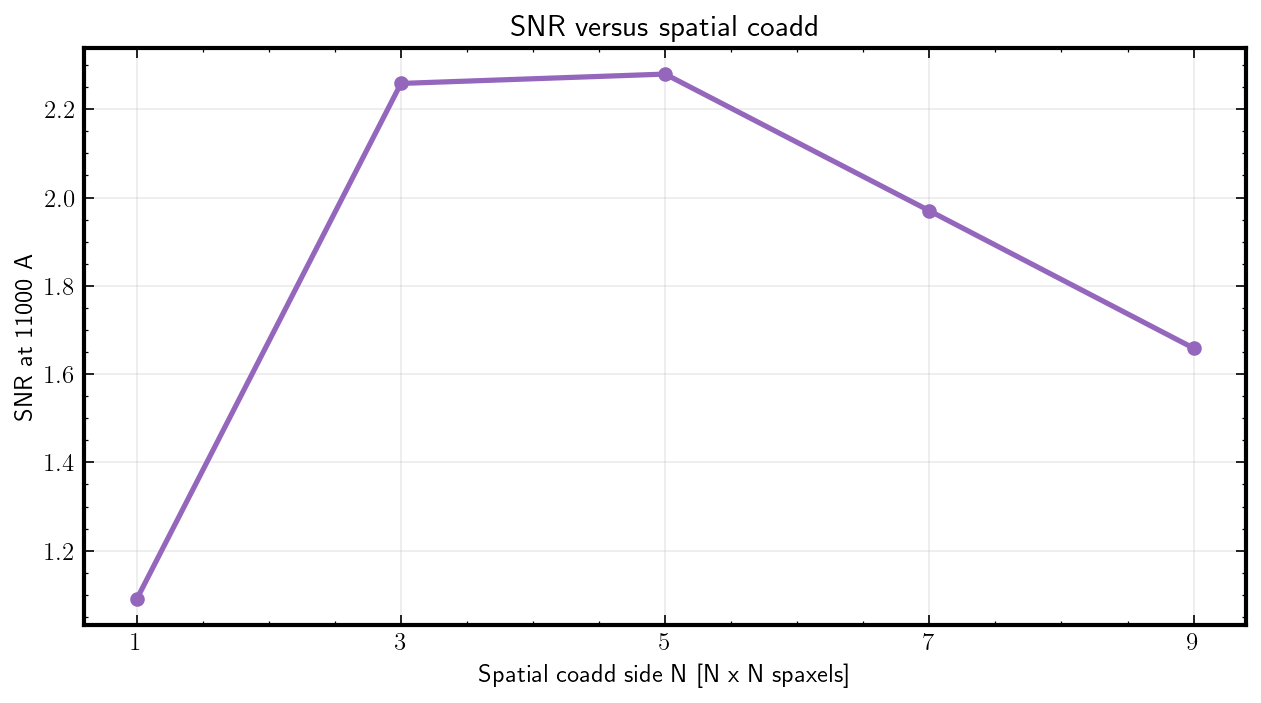

In [48]:
plt.plot(coadds, coadd_snr, 'o-', color='tab:purple')
plt.xlabel('Spatial coadd side N [N x N spaxels]')
plt.ylabel(f'SNR at {target_wave} A')
plt.title('SNR versus spatial coadd')
plt.xticks(coadds)
plt.show()

## 12. Resolved sources

For `Obj_Spat_Dis='resolved'`, add an image model. The ETC builds a normalized Moffat or Sersic profile and convolves it with the wavelength-dependent PSF before measuring the flux in the selected aperture.

Resolved image shape: (190, 190)
Resolved best coadd: 8


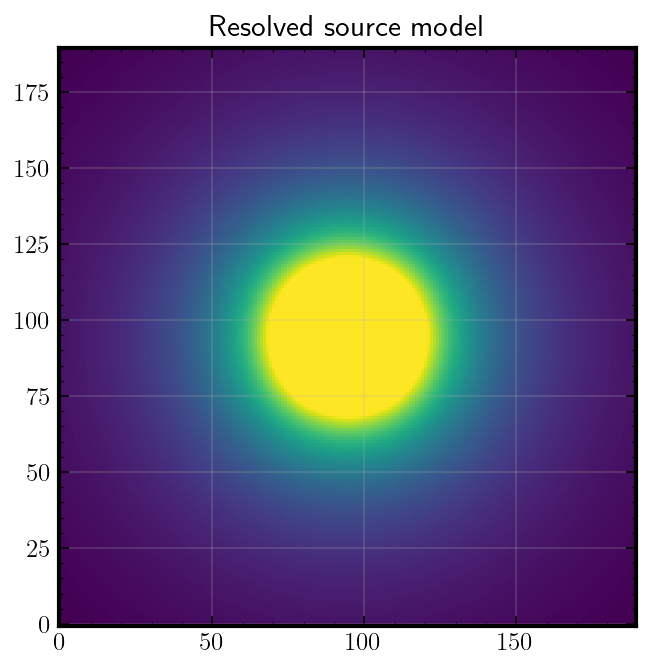

In [49]:
resolved_obs = dict(full_obs)
resolved_obs.update({
    'Obj_Spat_Dis': 'resolved',
    'IMA': 'sersic',
    'Sersic_Reff': 1.0,
    'Sersic_Ind': 2.0,
    'COADD_XY': 'best',
})

con_r, ob_r, spe_r, im_r, _ = redmuse.build_obs_full(resolved_obs)
res_r = redmuse.snr_from_source(con_r, im_r, spe_r, debug=False)

print('Resolved image shape:', im_r.data.shape)
print('Resolved best coadd:', ob_r['ima_coadd'])

plt.figure(figsize=(5, 5))
im_r.plot(zscale=True)
plt.title('Resolved source model')
plt.show()

## 13. Surface brightness and GLAO

For surface brightness, the source is specified per square arcsecond and the calculation is per spaxel; spatial PSF optimization is not used.

For IFS point and resolved sources, `GLAO=True` changes the wavelength-dependent image quality model and therefore changes the enclosed PSF fraction and optimal coadd.

In [51]:
def run_ifs_configuration(glao):
    demo_obs = dict(full_obs)
    demo_obs.update({'GLAO': glao, 'COADD_XY': 'best'})
    con_g, ob_g, spe_g, im_g, _ = redmuse.build_obs_full(demo_obs)
    result_g = redmuse.snr_at_wave(con_g, im_g, spe_g, wave_target=10000)
    return ob_g['ima_coadd'], result_g['snr_aperture']

coadd_nat, snr_nat = run_ifs_configuration(False)
coadd_glao, snr_glao = run_ifs_configuration(True)

print(f'Natural seeing: coadd={coadd_nat} x {coadd_nat}, SNR={snr_nat:.3f}')
print(f'GLAO:           coadd={coadd_glao} x {coadd_glao}, SNR={snr_glao:.3f}')
print(f'SNR change: {(snr_glao / snr_nat - 1) * 100:.1f}%')

[INFO] GLAO active (IFS): user seeing ignored, wavelength-dependent GLAO IQ formula applied; Moffat beta = 2.5
Natural seeing: coadd=4 x 4, SNR=2.361
GLAO:           coadd=2 x 2, SNR=4.226
SNR change: 79.0%


## 14. Useful result objects

The most useful products for exploration are:

| Object | Meaning |
|---|---|
| `res['spec']['nph_source']` | source counts in the extraction aperture |
| `res['spec']['nph_sky']` | sky counts in the extraction aperture |
| `res['spec']['noise']['tot']` | total noise |
| `res['spec']['snr']` | SNR per spectral pixel |
| `res['spec']['snr_rebin']` | SNR after spectral coadding, when requested |
| `res['peak']['snr']` | central-spaxel SNR for IFS |
| `res['spec']['simulated_counts']` | simulated extracted 1D detector counts |

The simulated 1D spectrum includes Poisson fluctuations from source, sky, and dark current, plus Gaussian read-out noise. It is a detector-count realization, not a calibrated or sky-subtracted spectrum.

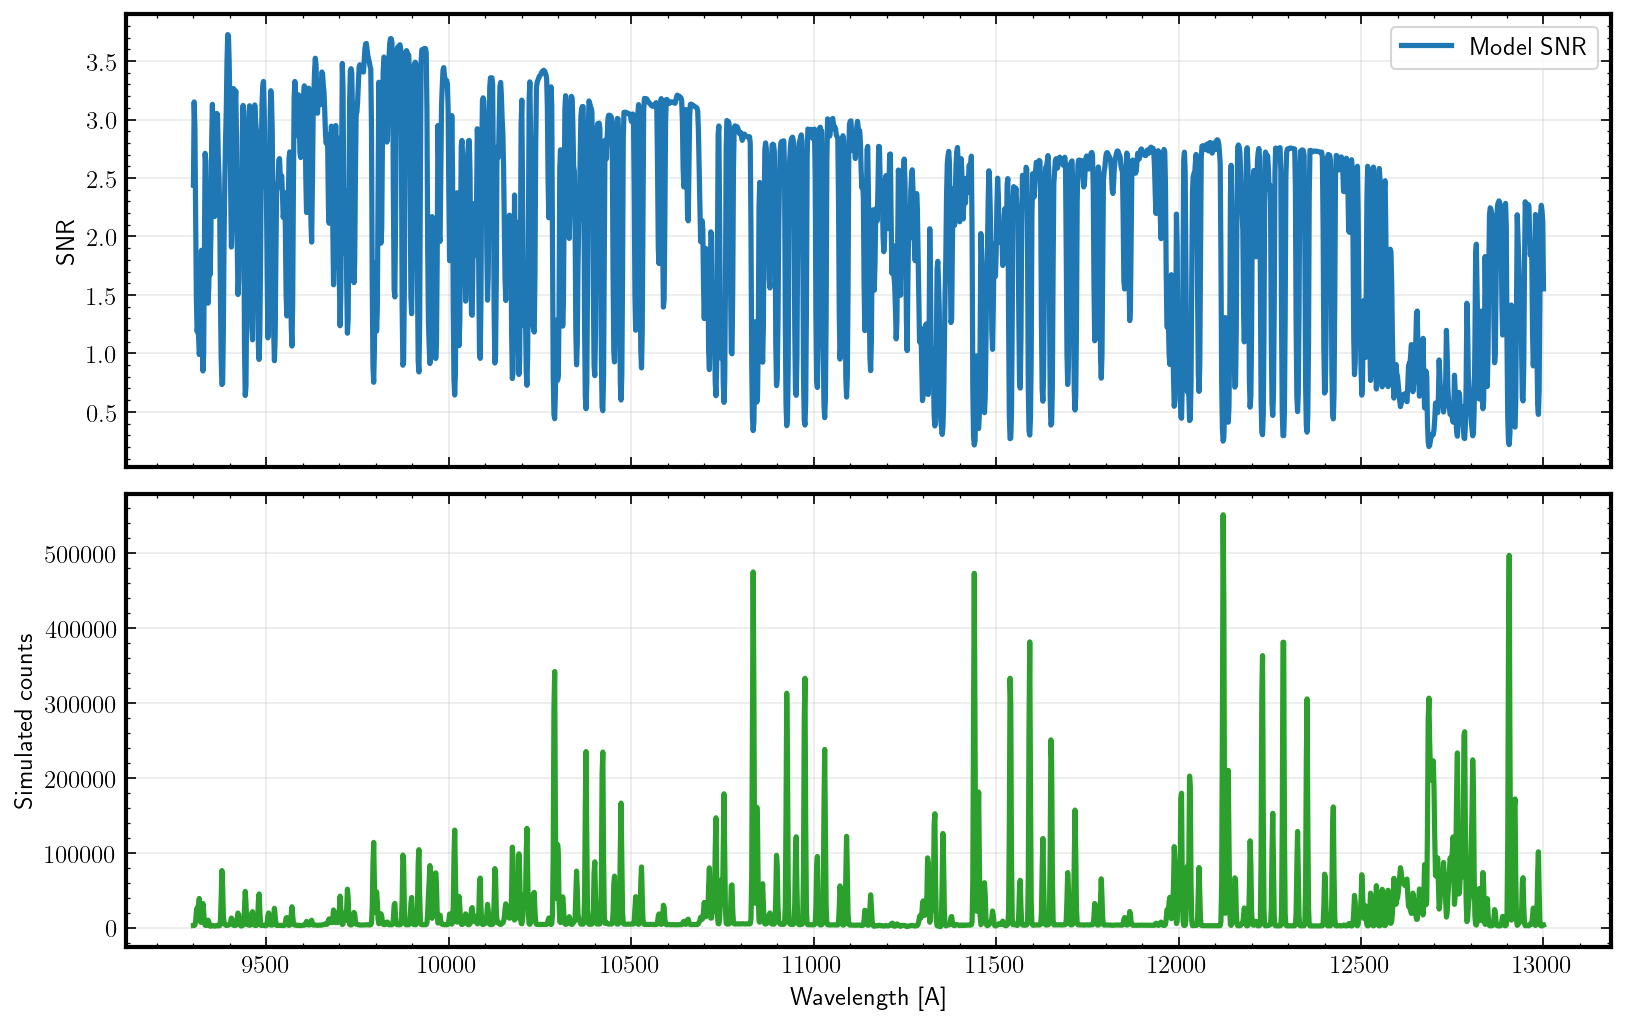

In [52]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
wave_result = res_snr['spec']['snr'].wave.coord()
axes[0].plot(wave_result, res_snr['spec']['snr'].data, label='Model SNR')
axes[0].set_ylabel('SNR')
axes[0].legend()

axes[1].plot(wave_result, res_snr['spec']['simulated_counts'].data, color='tab:green')
axes[1].set(xlabel='Wavelength [A]', ylabel='Simulated counts')
plt.tight_layout()
plt.show()

## 15. Switching to SkyCalc or another instrument

To request a fresh SkyCalc spectrum, set `SKYCALC=True` and choose a supported `PWV`, `FLI`, airmass, and moon separation. This requires the SkyCalc service and can be slower.


The source type and observation dictionary remain the same; only instrument-specific fields such as spatial coadd and fiber displacement need attention.

## Takeaway

The central workflow is always:

```text
full_obs -> build_obs_full -> (con, ob, spe, im) -> snr/time method -> result dictionaries -> plots
```

Once this pattern is familiar, you can build parameter scans over magnitude, seeing, GLAO, sky brightness, wavelength, morphology, DIT, NDIT, or spatial coadd without changing the ETC internals.

## 16. Read and plot API results

The web API returns a JSON dictionary. The configuration file is the input; the output file contains one result dictionary for every selected instrument and channel.

In the cells below we follow the simple workflow: load the file, inspect its dictionaries, select one result, and plot the arrays stored in `spectra`.

In [23]:
import json

import matplotlib.pyplot as plt



# Change this path to the JSON file produced by wst_cli.py.

with open('../../../../../Downloads/out_4.json', encoding='utf-8') as stream:

    data = json.load(stream)

### Inspect the API dictionaries

The top-level object contains `status` and `results`. Each element of `results` describes one configuration, while `spectra` contains the arrays sampled on the wavelength grid.

In [24]:
data.keys()

dict_keys(['results', 'status'])

In [25]:
data['results'][0].keys()

dict_keys(['DIT', 'NDIT', 'channel', 'configuration', 'instrument', 'sat_limit', 'saturated', 'snr_at_ref', 'spatial_coadd', 'spatial_coadd_auto', 'spectra'])

In [26]:
data['results'][0]['spectra'].keys()

dict_keys(['noise_frac_dark', 'noise_frac_ron', 'noise_frac_sky', 'noise_frac_source', 'noise_total', 'peak_counts', 'sky_counts', 'snr', 'source_counts', 'throughput_atmosphere', 'throughput_instrument', 'throughput_total', 'wave'])

### Select one configuration

The API may contain many configurations. Here we select one entry and assign the main arrays to short variables, exactly as in the standalone API-results notebook.

In [27]:
result = data['results'][0]

spectra = result['spectra']



wav = spectra['wave']

snr = spectra['snr']

source = spectra.get('source_counts')

sky = spectra.get('sky_counts')

noise = spectra.get('noise_total')



print(result['configuration'])

print('DIT:', result.get('DIT'), 'NDIT:', result.get('NDIT'))

print('SNR at reference:', result.get('snr_at_ref'))

IFS BLUE
DIT: 600.0 NDIT: 1
SNR at reference: {'snr': 321.64849797754226, 'wavelength': 5049.76}


### Plot one API product

This first plot is deliberately simple: the wavelength array is the x-axis and any numeric product from `spectra` can be plotted on the y-axis.

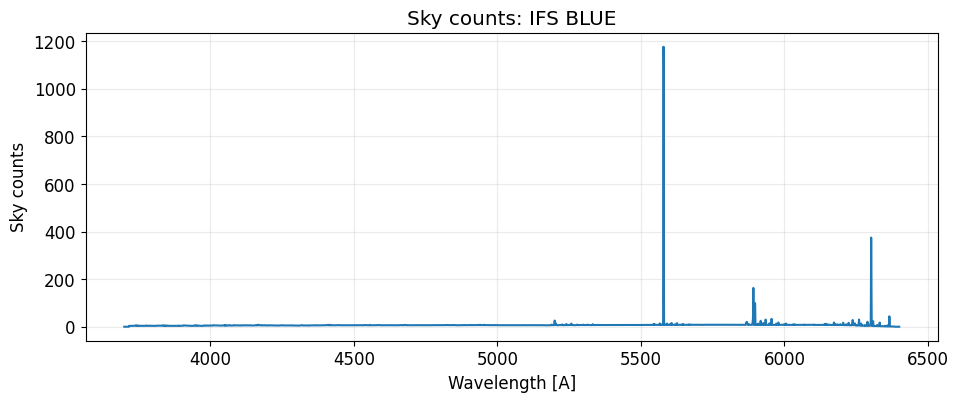

In [28]:
plt.figure(figsize=(11, 4))

plt.plot(wav, sky, color='tab:blue')

plt.xlabel('Wavelength [A]')

plt.ylabel('Sky counts')

plt.title(f"Sky counts: {result['configuration']}")

plt.show()

### Plot SNR, source, sky, and noise

These are the main curves returned by the API for the selected configuration. Some products may be absent depending on the instrument and computation mode, so `.get()` is useful when exploring results.

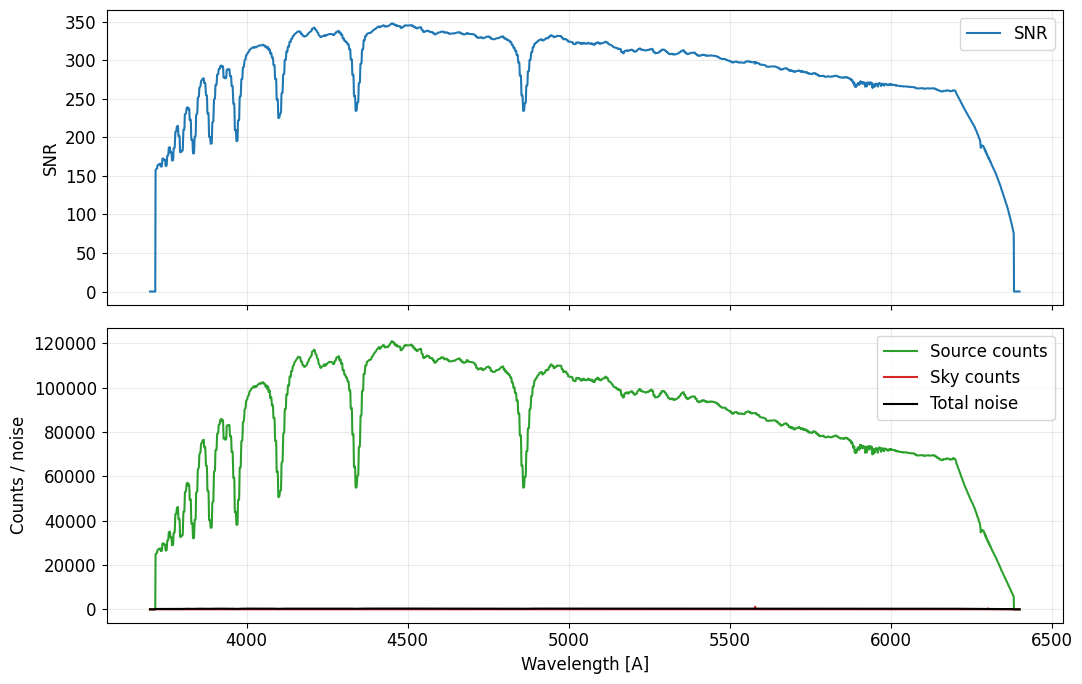

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)



axes[0].plot(wav, snr, label='SNR', color='tab:blue')

if 'snr_rebin' in spectra:

    axes[0].plot(spectra['wave_rebin'], spectra['snr_rebin'], label='SNR rebinned', color='tab:orange')

axes[0].set_ylabel('SNR')

axes[0].legend()



if source is not None:

    axes[1].plot(wav, source, label='Source counts', color='tab:green')

if sky is not None:

    axes[1].plot(wav, sky, label='Sky counts', color='tab:red')

if noise is not None:

    axes[1].plot(wav, noise, label='Total noise', color='black')

axes[1].set_xlabel('Wavelength [A]')

axes[1].set_ylabel('Counts / noise')

axes[1].legend()



plt.tight_layout()

plt.show()

### Plot throughput and noise fractions

The API also exports the transmission curves and, when available, the fractional contribution of source, sky, dark current, and RON to the total variance.

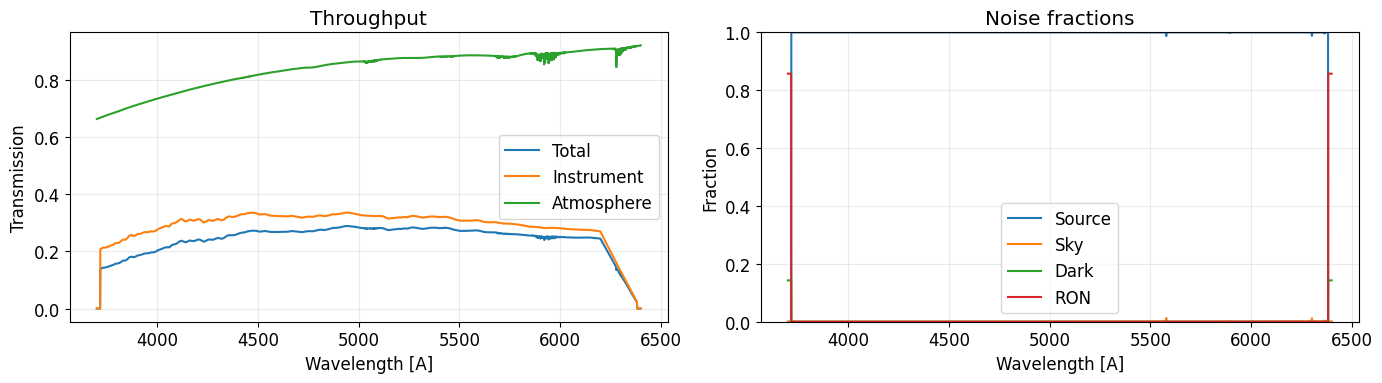

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))



for key, label in (

    ('throughput_total', 'Total'),

    ('throughput_instrument', 'Instrument'),

    ('throughput_atmosphere', 'Atmosphere'),

    ('throughput_fif', 'Fiber injection'),

):

    if key in spectra:

        axes[0].plot(wav, spectra[key], label=label)

axes[0].set(xlabel='Wavelength [A]', ylabel='Transmission', title='Throughput')

axes[0].legend()



for key, label in (

    ('noise_frac_source', 'Source'),

    ('noise_frac_sky', 'Sky'),

    ('noise_frac_dark', 'Dark'),

    ('noise_frac_ron', 'RON'),

):

    if key in spectra:

        axes[1].plot(wav, spectra[key], label=label)

axes[1].set(xlabel='Wavelength [A]', ylabel='Fraction', title='Noise fractions')

axes[1].set_ylim(0, 1)

axes[1].legend()



plt.tight_layout()

plt.show()